***1. Fengyuan 2F***

**Checking ARIMA assumptions for Fenyuan 2F**

Condition 1: Data Should be univariate-This condition is satisfied because we are considering only one orbital element that is, Brouwer Mean Motion

Condition 2: Are there any missing values in the data?

In [1]:
#Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
import numpy as np



In [2]:
# Load data
df = pd.read_csv('/content/Fengyun-2F.csv')
df['timestamp'] = pd.to_datetime(df['Unnamed: 0'])
df.set_index('timestamp', inplace=True)

# Check missing values
df['Brouwer mean motion'].isnull().sum()


0

Condition 3: Time Intervals should be regular



In [3]:
time_deltas = df.index.to_series().diff().value_counts()
print(time_deltas.head())


timestamp
1 days 00:07:15.943296    2
1 days 04:08:10.112064    1
0 days 23:29:32.899201    1
2 days 08:51:25.546751    1
0 days 15:30:25.980193    1
Name: count, dtype: int64


As we can see from the output. The condition is not met. We are fixing this using interpolation

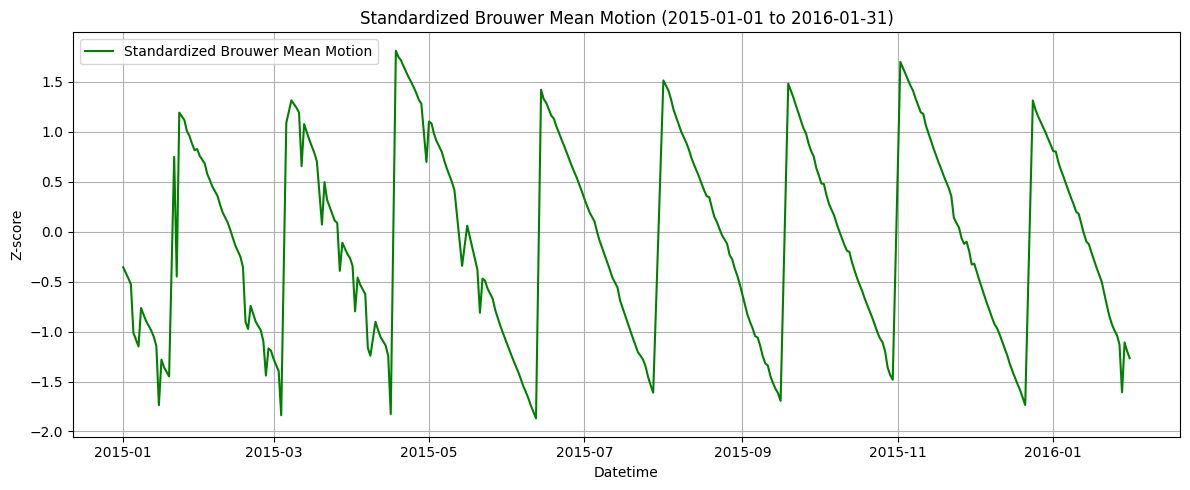

In [4]:
#Parse the timestamp column
df['timestamp'] = pd.to_datetime(df['Unnamed: 0'])
df.set_index('timestamp', inplace=True)

#Select the 'Brouwer mean motion' column
bmm_series = df['Brouwer mean motion']

#Step: Resampling
bmm_resampled = bmm_series.resample('D').mean()

#Using Linear Interpolation to fill the gaps
bmm_interpolated = bmm_resampled.interpolate(method='linear')

# Go back to full standardization
bmm_standardized = (bmm_interpolated-bmm_interpolated.mean())/bmm_interpolated.std()


# STEP 8: Define time window
start_date = '2015-01-01'
end_date = '2016-01-31'

# STEP 9: Filter standardized data
standardized_window = bmm_standardized[start_date:end_date]

# STEP 10: Plot only standardized data
plt.figure(figsize=(12, 5))
plt.plot(standardized_window, label='Standardized Brouwer Mean Motion', color='green')
plt.title(f'Standardized Brouwer Mean Motion ({start_date} to {end_date})')
plt.xlabel('Datetime')
plt.ylabel('Z-score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Condition 4: The data should be stationery. For ARIMA it is necessary that mean and variance are consistent  over time (meaning they dont have any trend, seasonality and changing variance)

In [5]:
# Checking through ADF- Statistical Test
from statsmodels.tsa.stattools import adfuller

# Run ADF Test
result = adfuller(bmm_standardized.dropna())

print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")

if result[1] < 0.05:
    print("✅ The series is stationary (p < 0.05)")
else:
    print("❌ The series is NOT stationary (p ≥ 0.05)")


ADF Statistic: -18.720553354473488
p-value: 2.032774752880195e-30
✅ The series is stationary (p < 0.05)


In [6]:
# Perform ADF test on the standardized series
adf_result = adfuller(bmm_standardized.dropna())  # Drop NaNs to avoid issues

# Print ADF test results
print("\nAugmented Dickey-Fuller Test Results:")
print(f"ADF Statistic      : {adf_result[0]}")
print(f"p-value            : {adf_result[1]}")
print(f"# Lags Used        : {adf_result[2]}")
print(f"# Observations Used: {adf_result[3]}")
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value}")

# STEP 13: Conclusion based on p-value
alpha = 0.05
if adf_result[1] < alpha:
    print("\n✅ Conclusion: The time series is likely **stationary** (reject H₀).")
else:
    print("\n❌ Conclusion: The time series is likely **non-stationary** (fail to reject H₀).")



Augmented Dickey-Fuller Test Results:
ADF Statistic      : -18.720553354473488
p-value            : 2.032774752880195e-30
# Lags Used        : 30
# Observations Used: 3384
Critical Values:
   1%: -3.432283885147278
   5%: -2.8623944783328996
   10%: -2.5672248552253967

✅ Conclusion: The time series is likely **stationary** (reject H₀).


Condition 5: Choose d,p,q values

Since our data is already stationery, we choose d=0

Choosing p and q using 'auto_arima'

In [7]:
!pip install pmdarima


In [8]:
# !pip uninstall -y numpy pmdarima
# !pip install numpy==1.23.5
# !pip install pmdarima --no-binary :all: #Run this once and restart the session



In [9]:
from pmdarima.arima import auto_arima
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.graphics.gofplots import qqplot
import warnings
warnings.filterwarnings("ignore")

# Input series (already standardised and interpolated)
series_for_arima = bmm_standardized.dropna()

# 🔍 Automatically determine best ARIMA(p,d,q) using full search
model_auto = auto_arima(
    series_for_arima,
    start_p=0, max_p=5,
    start_q=0, max_q=5,
    d=0,
    seasonal=False,
    stepwise=False,
    trace=True,
    suppress_warnings=True,
    error_action='ignore'
)

print("\n✅ Best ARIMA model selected by auto_arima:")
print(model_auto.summary())


 ARIMA(0,0,0)(0,0,0)[0]             : AIC=9692.350, Time=0.05 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=6656.135, Time=0.40 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=5230.504, Time=1.47 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=4568.673, Time=1.72 sec
 ARIMA(0,0,4)(0,0,0)[0]             : AIC=4202.232, Time=2.47 sec
 ARIMA(0,0,5)(0,0,0)[0]             : AIC=3991.271, Time=4.91 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=3751.252, Time=0.93 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=3669.202, Time=1.79 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=3665.664, Time=2.07 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=3663.300, Time=2.27 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=3659.396, Time=4.56 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=3662.678, Time=2.41 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=3501.168, Time=5.50 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=3477.437, Time=9.16 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=3477.482, Time=3.67 sec
 ARIMA(3,0

Hence p=4, d=0, q=1

Condition 6: Residuals should be white noise

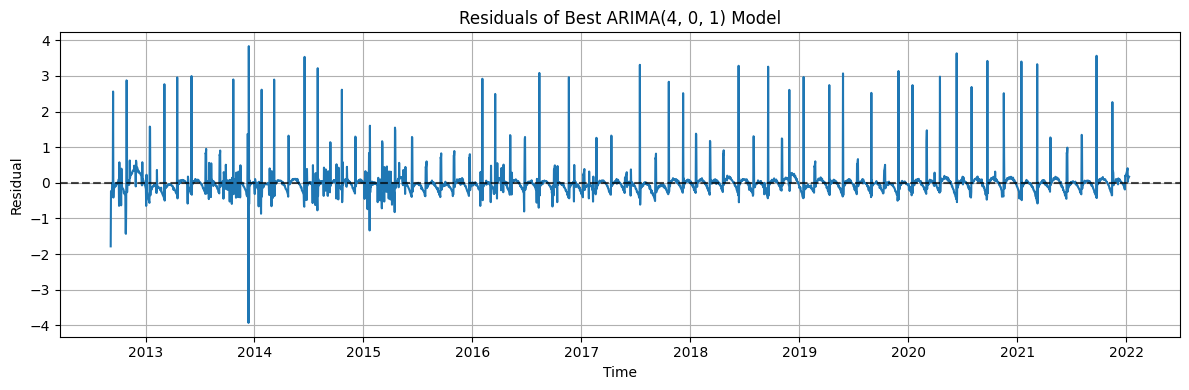

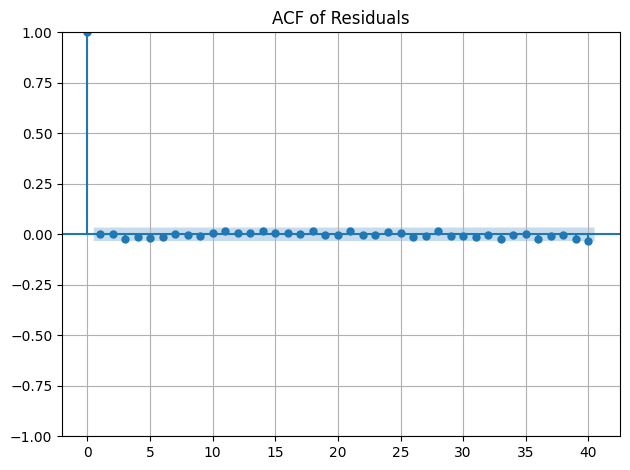

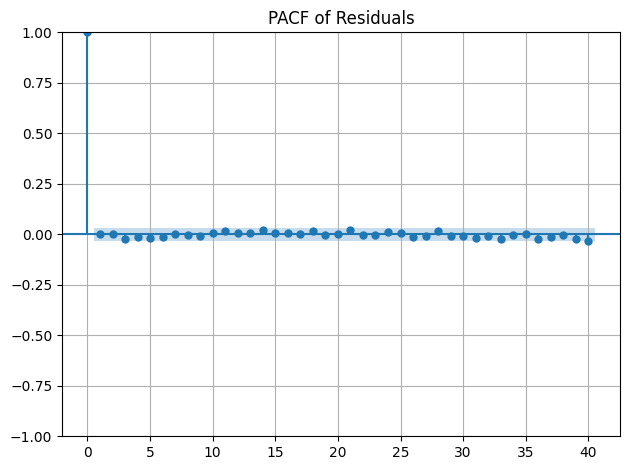

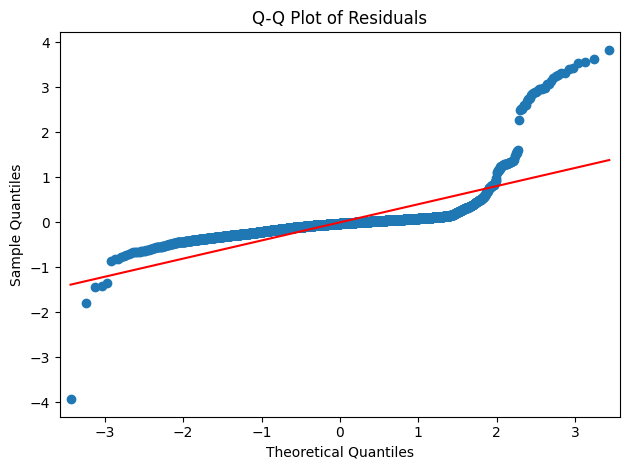


📊 Ljung-Box Test Results:
      lb_stat  lb_pvalue
10   3.977061   0.948376
20   7.273116   0.995688
30  11.647589   0.998949

✅ Conclusion: Residuals resemble **white noise** (no significant autocorrelation).


In [10]:
# Fit the selected model using statsmodels for residual analysis
best_params = model_auto.order
best_model = sm.tsa.ARIMA(series_for_arima, order=best_params).fit()

# Extract residuals
residuals = best_model.resid.dropna()

# 1. Residual time series plot
plt.figure(figsize=(12, 4))
plt.plot(residuals)
plt.axhline(0, color='black', linestyle='--', alpha=0.7)
plt.title(f'Residuals of Best ARIMA{best_params} Model')
plt.xlabel('Time')
plt.ylabel('Residual')
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. ACF plot
plot_acf(residuals, lags=40)
plt.title('ACF of Residuals')
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. PACF plot
plot_pacf(residuals, lags=40, method='ywm')
plt.title('PACF of Residuals')
plt.grid(True)
plt.tight_layout()
plt.show()

# 4. Q-Q Plot
qqplot(residuals, line='s')
plt.title('Q-Q Plot of Residuals')
plt.tight_layout()
plt.show()

# 5. Ljung-Box Test
ljung_box = acorr_ljungbox(residuals, lags=[10, 20, 30], return_df=True)
print("\n📊 Ljung-Box Test Results:")
print(ljung_box)

# 6. Conclusion based on p-values
if (ljung_box['lb_pvalue'] > 0.05).all():
    print("\n✅ Conclusion: Residuals resemble **white noise** (no significant autocorrelation).")
else:
    print("\n❌ Conclusion: Residuals show **autocorrelation** (not white noise). Model may be misspecified.")

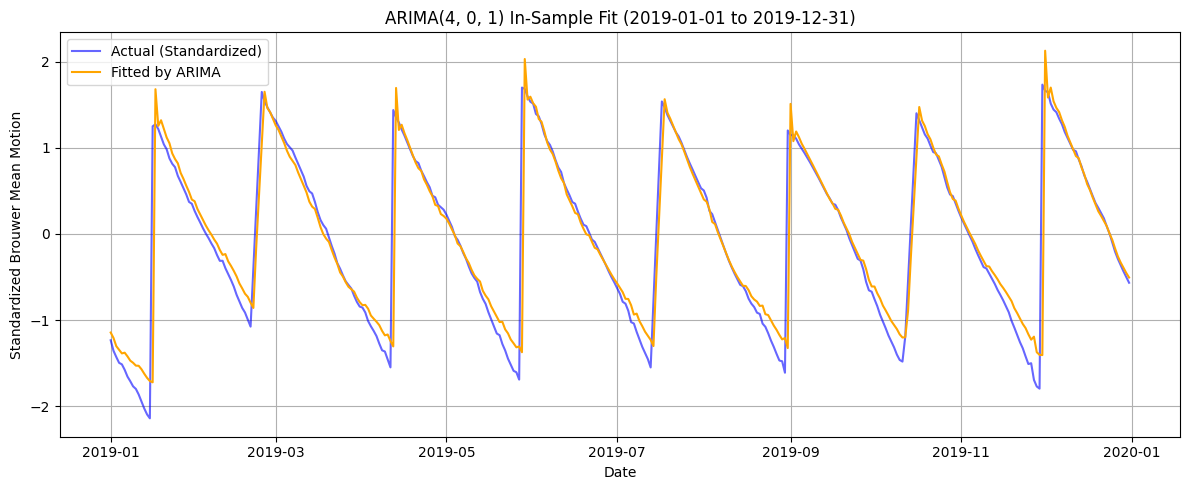

In [11]:
from statsmodels.tsa.arima.model import ARIMA
# Step 1: Refit the best ARIMA model on standardized series
model_trad = ARIMA(bmm_standardized, order=best_params)
model_trad_fit = model_trad.fit()

# Step 2: Get in-sample fitted values
fitted_values = model_trad_fit.predict(start=0, end=len(bmm_standardized)-1)

# Step 3: Define time interval
start_date = '2019-01-01'
end_date = '2019-12-31'

# Step 4: Filter both actual and fitted series to the time window
actual_window = bmm_standardized[start_date:end_date]
fitted_window = fitted_values[start_date:end_date]

# Step 5: Plot only the windowed data (y-axis adjusts dynamically)
plt.figure(figsize=(12, 5))
plt.plot(actual_window, label='Actual (Standardized)', color='blue', alpha=0.6)
plt.plot(fitted_window, label='Fitted by ARIMA', color='orange')
plt.title(f'ARIMA{best_params} In-Sample Fit ({start_date} to {end_date})')
plt.xlabel('Date')
plt.ylabel('Standardized Brouwer Mean Motion')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


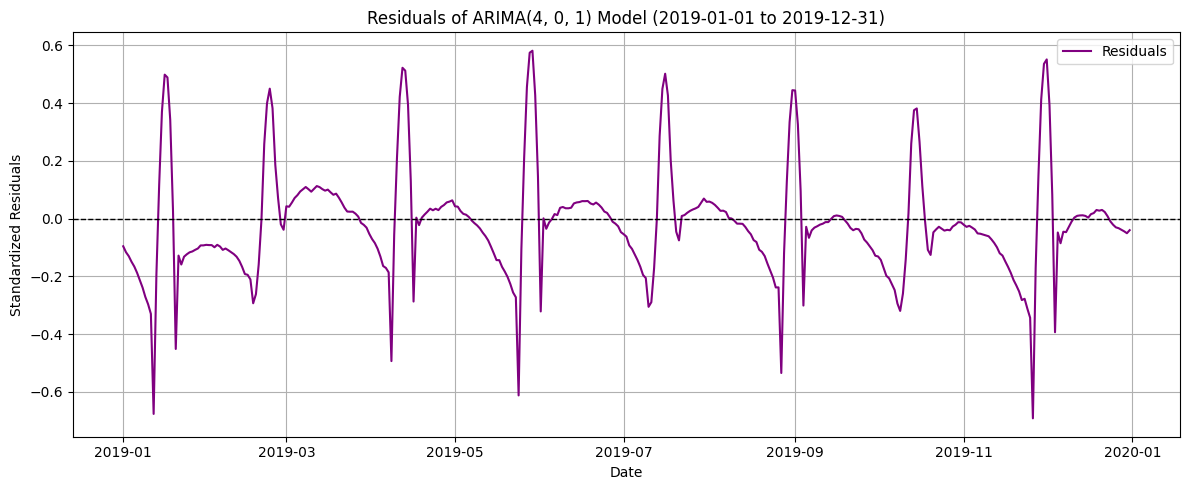

In [12]:
from scipy.signal import savgol_filter

# Step 1: Get residuals from the best ARIMA model
residuals = model_trad_fit.resid

# Step 2: Smooth the residuals (window length must be odd and < len(data))
smoothed_residuals = pd.Series(
    savgol_filter(residuals, window_length=9, polyorder=2),
    index=residuals.index
)


# Step 2: Define the desired time interval
start_date = '2019-01-01'
end_date = '2019-12-31'

# Step 3: Filter residuals to that time interval
residuals_window = smoothed_residuals[start_date:end_date]

# Step 4: Plot residuals (auto y-axis)
plt.figure(figsize=(12, 5))
plt.plot(residuals_window, label='Residuals', color='purple')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title(f'Residuals of ARIMA{best_params} Model ({start_date} to {end_date})')
plt.xlabel('Date')
plt.ylabel('Standardized Residuals')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


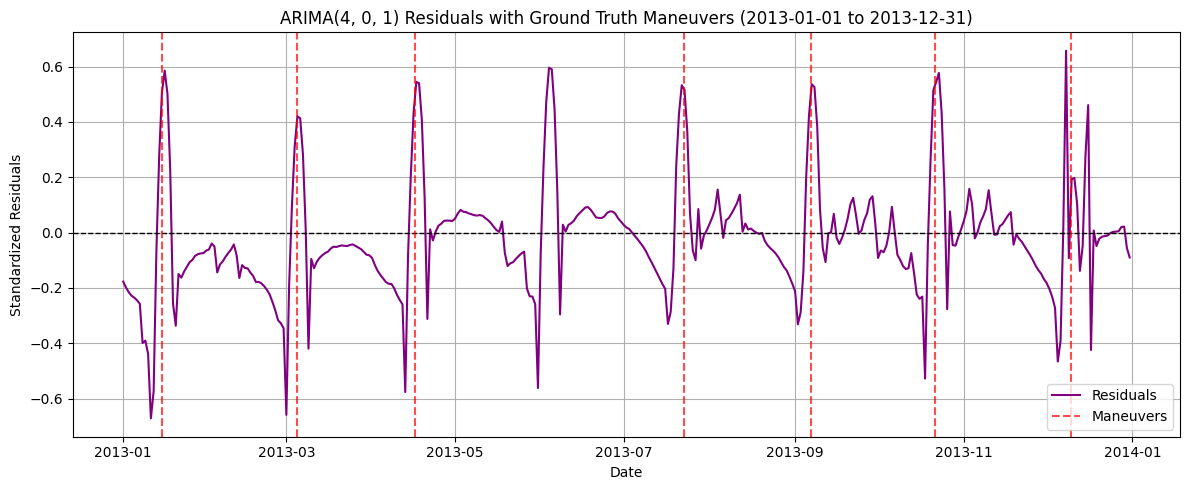

In [13]:
#Load maneuver ground truth
truth_df = pd.read_excel("/content/manFY2F_cleaned.xlsx")

#Create maneuver timestamps by combining date and time
truth_df["Maneuver_Timestamp"] = pd.to_datetime(
    truth_df["Start Date"].astype(str) + " " + truth_df["Start Time"].astype(str)
)

#Define time window
start_date = '2013-01-01'
end_date = '2013-12-31'

#Filter maneuver timestamps to the defined window
filtered_maneuvers = truth_df[
    (truth_df["Maneuver_Timestamp"] >= start_date) &
    (truth_df["Maneuver_Timestamp"] <= end_date)
]["Maneuver_Timestamp"]


#Get residuals from the best ARIMA model for the same window
residuals_window = smoothed_residuals[start_date:end_date]

# Plot
plt.figure(figsize=(12, 5))
res_line, = plt.plot(residuals_window, label='Residuals', color='purple')
plt.axhline(0, color='black', linestyle='--', linewidth=1)

# Plot one representative maneuver line for legend
man_line = plt.axvline(x=filtered_maneuvers.iloc[0], color='red', linestyle='--', alpha=0.7, label='Maneuvers')

# Plot the rest (without labels)
for ts in filtered_maneuvers.iloc[1:]:
    plt.axvline(x=ts, color='red', linestyle='--', alpha=0.7)

# Formatting
plt.title(f'ARIMA{best_params} Residuals with Ground Truth Maneuvers ({start_date} to {end_date})')
plt.xlabel('Date')
plt.ylabel('Standardized Residuals')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



In [14]:
#Absolute residuals from best ARIMA model
abs_resid = smoothed_residuals.abs()

#Set threshold using global mean and std deviation
mean_resid = abs_resid.mean()
std_resid = abs_resid.std()
k = 2.0

threshold = mean_resid + k * std_resid

#Detect maneuvers
detections = abs_resid[abs_resid > threshold]
detected_maneuver_timestamps = pd.to_datetime(detections.index)
print(f"Detected {len(detections)} maneuver events.")


Detected 223 maneuver events.


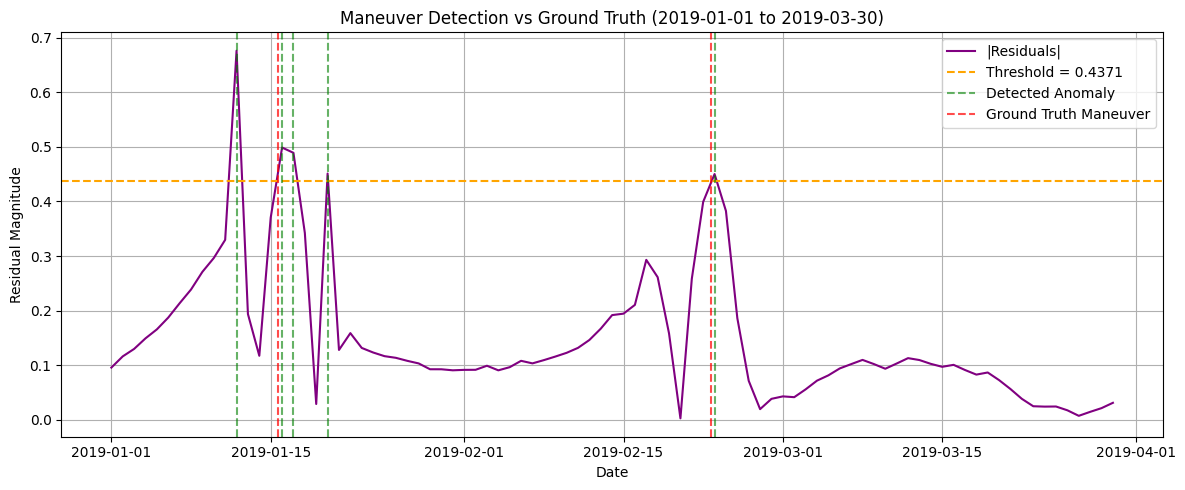

In [15]:
#Define time window
start_date = '2019-01-01'
end_date = '2019-03-30'

#Filter residuals to the time window
resid_window = abs_resid[start_date:end_date]

#Filter detected maneuver timestamps to this window
detected_in_window = [ts for ts in detected_maneuver_timestamps if start_date <= str(ts) <= end_date]

#Ground truth maneuver timestamps (already parsed)
truth_df["Maneuver_Timestamp"] = pd.to_datetime(
    truth_df["Start Date"].astype(str) + " " + truth_df["Start Time"].astype(str)
)
true_maneuvers_window = truth_df[
    (truth_df["Maneuver_Timestamp"] >= start_date) &
    (truth_df["Maneuver_Timestamp"] <= end_date)
]["Maneuver_Timestamp"]

#Plot
plt.figure(figsize=(12, 5))
plt.plot(resid_window, label='|Residuals|', color='purple')
plt.axhline(y=threshold, color='orange', linestyle='--', label=f'Threshold = {threshold:.4f}')

# Add one label for detected maneuvers
for i, ts in enumerate(detected_in_window):
    plt.axvline(x=ts, color='green', linestyle='--', alpha=0.6,
                label='Detected Anomaly' if i == 0 else "")

# Add one label for ground truth maneuvers
for i, ts in enumerate(true_maneuvers_window):
    plt.axvline(x=ts, color='red', linestyle='--', alpha=0.7,
                label='Ground Truth Maneuver' if i == 0 else "")

# Final formatting
plt.title(f'Maneuver Detection vs Ground Truth ({start_date} to {end_date})')
plt.xlabel('Date')
plt.ylabel('Residual Magnitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Extra steps which are not mentioned in the paper

In [16]:
from statsmodels.robust.scale import mad
#Residuals from your model
residuals_trad = model_trad_fit.resid
abs_residuals = residuals_trad.abs()
all_timestamps = abs_residuals.index  # should be 2375 timestamps

#Rolling MAD-based adaptive threshold
window = 30
rolling_median = abs_residuals.rolling(window=window, center=True).median()
rolling_mad = abs_residuals.rolling(window=window, center=True).apply(lambda x: mad(x), raw=True)

k = 8.2
adaptive_threshold = rolling_median + k * rolling_mad
relaxed_cutoff = abs_residuals.quantile(0.90)

strong_spikes = abs_residuals > adaptive_threshold
above_floor = abs_residuals > relaxed_cutoff
detected_spikes = abs_residuals[strong_spikes & above_floor]

#Ground truth maneuver timestamps
ground_truth_timestamps = pd.to_datetime(
    truth_df["Start Date"].astype(str) + " " + truth_df["Start Time"].astype(str)
)
print(f"Total ground truth maneuvers: {len(ground_truth_timestamps)}")

#Rescue borderline spikes near ground truth
rescue_window = pd.Timedelta(hours=6)
rescue_threshold = abs_residuals.quantile(0.85)
rescue_candidates = abs_residuals[(~strong_spikes) & (abs_residuals > rescue_threshold)]

rescued = []
for ts in rescue_candidates.index:
    if any(abs(ts - gt) <= rescue_window for gt in ground_truth_timestamps):
        rescued.append(ts)

rescued_series = abs_residuals.loc[rescued]
detected_spikes = pd.concat([detected_spikes, rescued_series]).sort_index()

#Collapse into 10-hour groups
collapsed = []
buffer = pd.Timedelta(hours=10)
sorted_timestamps = detected_spikes.index.sort_values()

if len(sorted_timestamps) > 0:
    group = [sorted_timestamps[0]]
    for i in range(1, len(sorted_timestamps)):
        if sorted_timestamps[i] - group[-1] <= buffer:
            group.append(sorted_timestamps[i])
        else:
            max_ts = abs_residuals.loc[group].idxmax()
            collapsed.append(max_ts)
            group = [sorted_timestamps[i]]
    max_ts = abs_residuals.loc[group].idxmax()
    collapsed.append(max_ts)

#Filter out events too close to each other (<8h)
final_collapsed = []
for i in range(len(collapsed)):
    if i == 0 or (collapsed[i] - final_collapsed[-1]) > pd.Timedelta(hours=8):
        final_collapsed.append(collapsed[i])

#Filter predictions far from GT (optional)
tolerance = pd.Timedelta(days=1.5)
final_collapsed = [
    ts for ts in final_collapsed
    if any(abs(ts - gt) <= tolerance for gt in ground_truth_timestamps)
]

collapsed_maneuvers = pd.to_datetime(final_collapsed)

#Event-level Evaluation
tp = 0
matched_gt = set()

for det in collapsed_maneuvers:
    for i, gt in enumerate(ground_truth_timestamps):
        if i in matched_gt:
            continue
        if abs(det - gt) <= tolerance:
            tp += 1
            matched_gt.add(i)
            break

fp = len(collapsed_maneuvers) - tp
fn = len(ground_truth_timestamps) - tp
tn = len(all_timestamps) - (tp + fp + fn)  # TN is everything else

#Metrics
precision = tp / (tp + fp) if (tp + fp) else 0
recall = tp / (tp + fn) if (tp + fn) else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0

#Output
print(f"\n✅ Final Evaluation (Event-Level)")
print(f"TP: {tp}, FP: {fp}, FN: {fn}, TN: {tn}")
print(f"Precision: {precision:.2f}, Recall: {recall:.2f}, F1 Score: {f1:.2f}")

print("\nConfusion Matrix (Event-Level):")
print("                  Predicted: No | Predicted: Yes")
print(f"Actual: No     |     {tn:>6}       |     {fp:>4}")
print(f"Actual: Yes    |     {fn:>6}       |     {tp:>4}")

#Check total
total = tp + fp + fn + tn
print(f"\n✅ Total Evaluated Observations: {total} (should equal {len(bmm_standardized)})")


Total ground truth maneuvers: 68

✅ Final Evaluation (Event-Level)
TP: 44, FP: 13, FN: 24, TN: 3334
Precision: 0.77, Recall: 0.65, F1 Score: 0.70

Confusion Matrix (Event-Level):
                  Predicted: No | Predicted: Yes
Actual: No     |       3334       |       13
Actual: Yes    |         24       |       44

✅ Total Evaluated Observations: 3415 (should equal 3415)


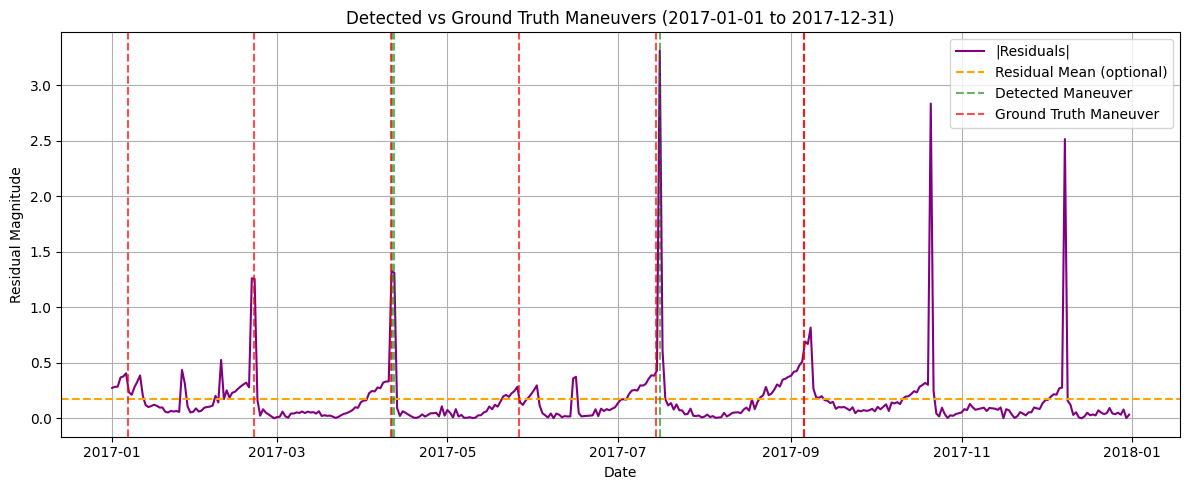

In [17]:
# Define your plotting window (change if needed)
start_date = '2017-01-01'
end_date = '2017-12-31'

#Filter residuals
resid_window = abs_residuals[start_date:end_date]

#Filter detected maneuvers to that window
detected_in_window = [ts for ts in final_collapsed if start_date <= str(ts) <= end_date]

#Filter GT maneuvers to that window
gt_window = ground_truth_timestamps[
    (ground_truth_timestamps >= pd.to_datetime(start_date)) &
    (ground_truth_timestamps <= pd.to_datetime(end_date))
]

#Plot residuals and maneuvers
plt.figure(figsize=(12, 5))
plt.plot(resid_window, label='|Residuals|', color='purple')
plt.axhline(y=abs_residuals.mean(), color='orange', linestyle='--', label='Residual Mean (optional)')

# Plot detected maneuvers
for i, ts in enumerate(detected_in_window):
    plt.axvline(x=ts, color='green', linestyle='--', alpha=0.6, label='Detected Maneuver' if i == 0 else "")

# Plot actual maneuvers
for i, ts in enumerate(gt_window):
    plt.axvline(x=ts, color='red', linestyle='--', alpha=0.7, label='Ground Truth Maneuver' if i == 0 else "")

# Final formatting
plt.title(f'Detected vs Ground Truth Maneuvers ({start_date} to {end_date})')
plt.xlabel('Date')
plt.ylabel('Residual Magnitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
